In [ ]:

import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random

Mounted at /content/gdrive


In [ ]:

data_root = os.path.join('..', 'data', 'ISIC2018')
train_img_dir = os.path.join(data_root, 'ISIC2018_Task1-2_Training_Input')
train_mask_dir = os.path.join(data_root, 'ISIC2018_Task1_Training_GroundTruth')

val_img_dir = os.path.join(data_root, 'ISIC2018_Task1-2_Validation_Input')
val_mask_dir = os.path.join(data_root, 'ISIC2018_Task1_Validation_GroundTruth')

test_img_dir = os.path.join(data_root, 'ISIC2018_Task1-2_Test_Input')
test_mask_dir = os.path.join(data_root, 'ISIC2018_Task1_Test_GroundTruth')

train_img = sorted(glob.glob(os.path.join(train_img_dir, '*.jpg')))
train_mask = sorted(glob.glob(os.path.join(train_mask_dir, '*.png')))

val_img = sorted(glob.glob(os.path.join(val_img_dir, '*.jpg')))
val_mask = sorted(glob.glob(os.path.join(val_mask_dir, '*.png')))

test_img = sorted(glob.glob(os.path.join(test_img_dir, '*.jpg')))
test_mask = sorted(glob.glob(os.path.join(test_mask_dir, '*.png')))

print("✅ Đã nạp xong đường dẫn dữ liệu!")
print(f" 📦 Tập Huấn luyện (Train): {len(train_img)} ảnh | {len(train_mask)} mặt nạ")
print(f" 📦 Tập Xác thực (Validation): {len(val_img)} ảnh | {len(val_mask)} mặt nạ")
print(f" 📦 Tập Kiểm tra (Test): {len(test_img)} ảnh | {len(test_mask)} mặt nạ")



✅ Đã nạp xong đường dẫn dữ liệu!
 📦 Tập Huấn luyện (Train): 2594 ảnh | 2594 mặt nạ
 📦 Tập Xác thực (Validation): 100 ảnh | 100 mặt nạ
 📦 Tập Kiểm tra (Test): 1000 ảnh | 1000 mặt nạ


⚙️ ĐANG PHÂN TÍCH KÍCH THƯỚC ẢNH TRONG TẬP TRAIN...


100%|██████████| 2594/2594 [09:02<00:00,  4.78it/s]


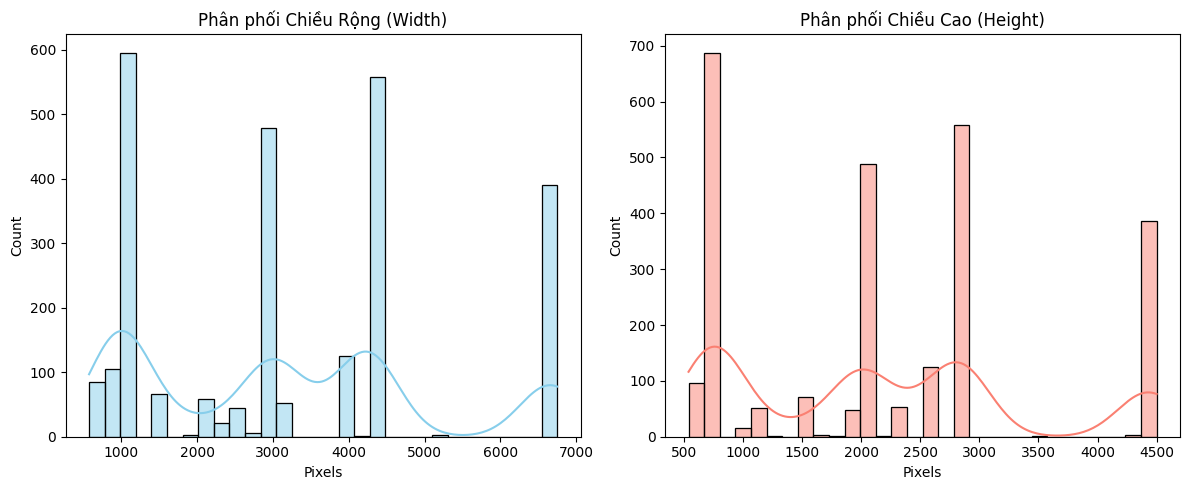

📊 Thống kê nhanh:
 - Rộng (Width) : Min 576 | Max 6748 | Trung bình 3188
 - Cao (Height) : Min 540 | Max 4499 | Trung bình 2166


In [ ]:
print("⚙️ ĐANG PHÂN TÍCH KÍCH THƯỚC ẢNH TRONG TẬP TRAIN...")

widths, heights = [], []

for img_path in tqdm(train_img):
    shape = cv2.imread(img_path).shape
    heights.append(shape[0])
    widths.append(shape[1])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(widths, bins=30, color='skyblue', kde=True)
plt.title("Phân phối Chiều Rộng (Width)")
plt.xlabel("Pixels")

plt.subplot(1, 2, 2)
sns.histplot(heights, bins=30, color='salmon', kde=True)
plt.title("Phân phối Chiều Cao (Height)")
plt.xlabel("Pixels")

plt.tight_layout()
plt.show()

print(f"📊 Thống kê nhanh:")
print(f" - Rộng (Width) : Min {min(widths)} | Max {max(widths)} | Trung bình {int(np.mean(widths))}")
print(f" - Cao (Height) : Min {min(heights)} | Max {max(heights)} | Trung bình {int(np.mean(heights))}")


🔍 ĐANG BỐC NGẪU NHIÊN 4 ẢNH ĐỂ TRỰC QUAN HÓA...


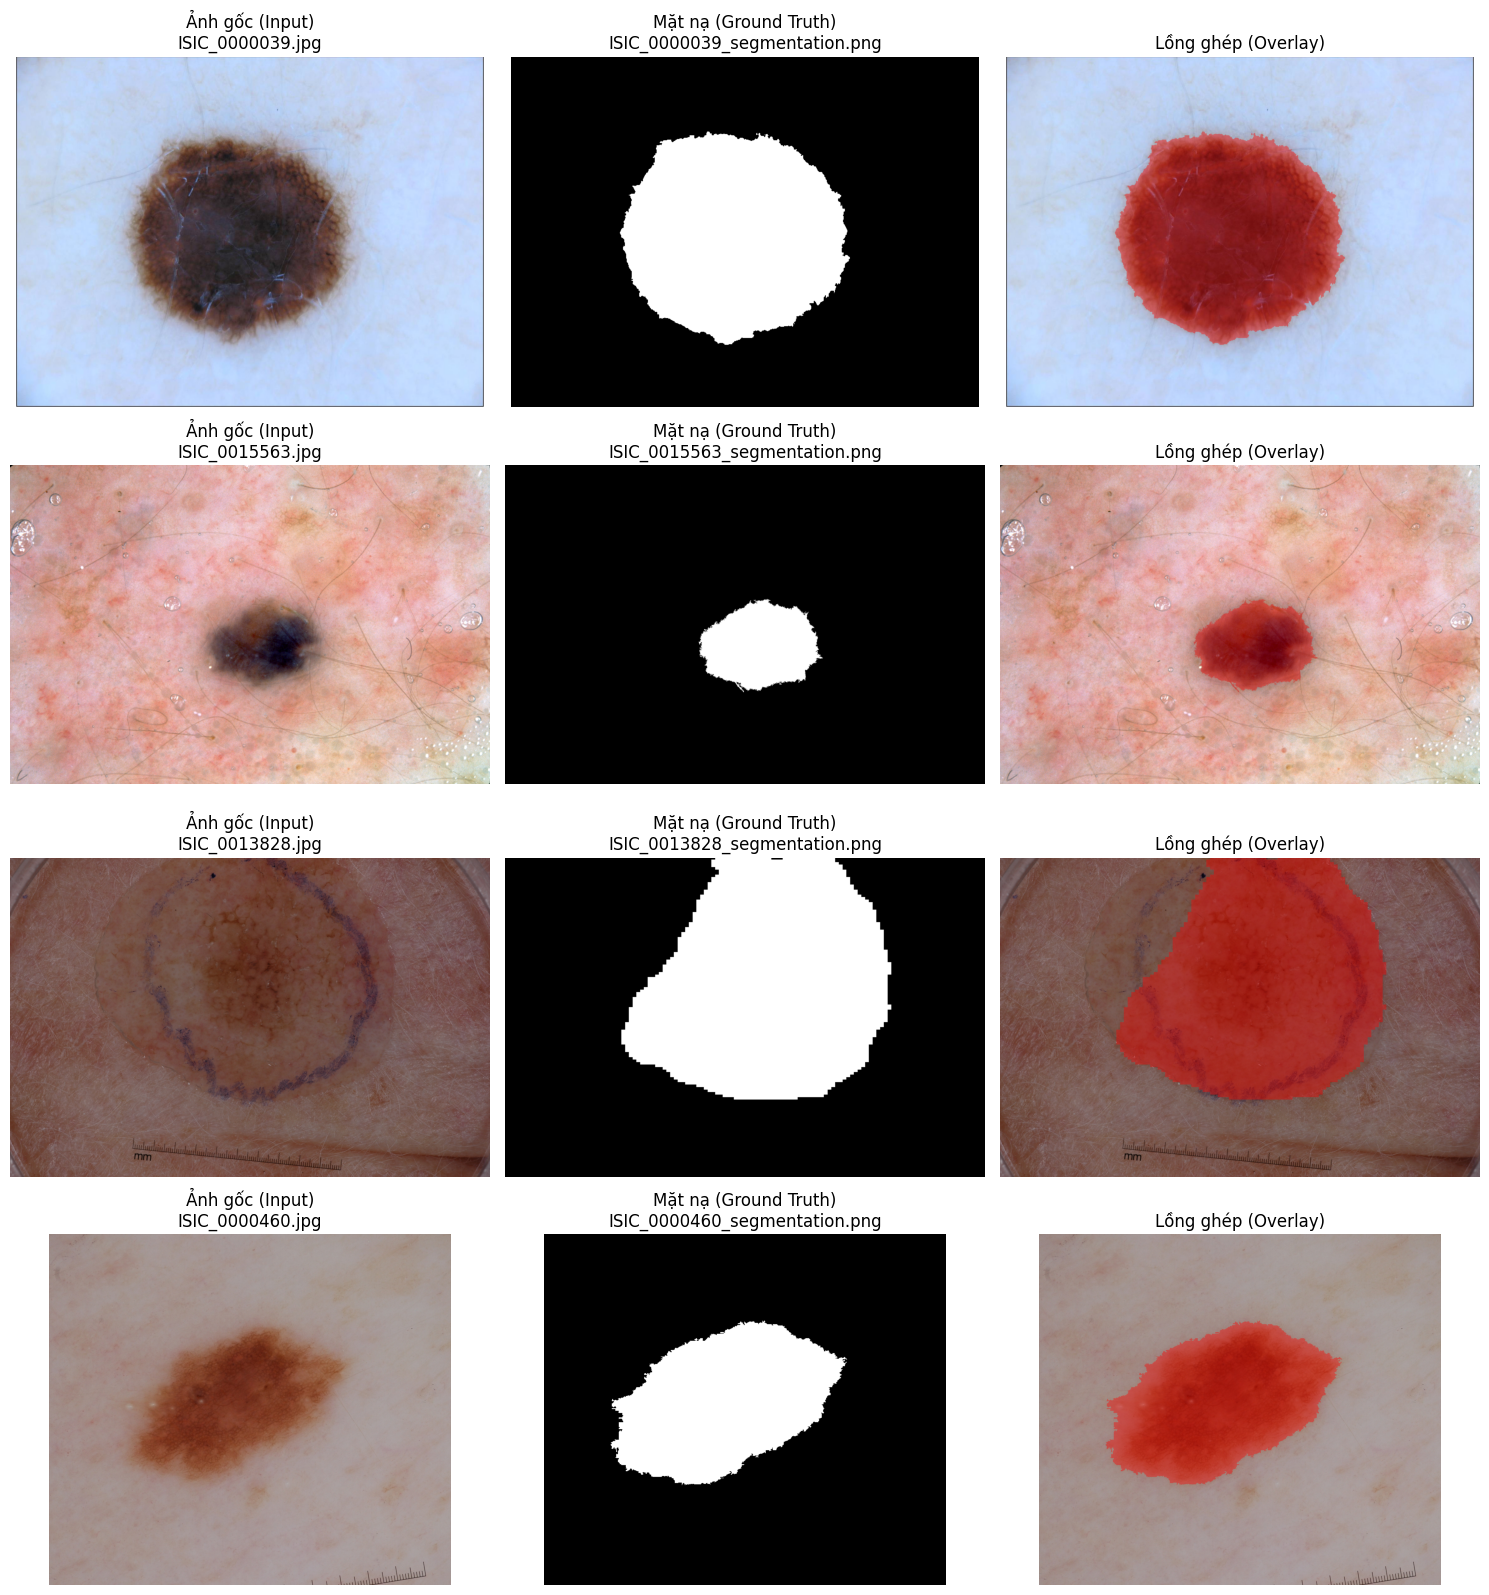

In [4]:
def visualize_samples(image_list, mask_list, num_samples=4):
    indices = random.sample(range(len(image_list)), num_samples)

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

    for i, idx in enumerate(indices):
        img = cv2.imread(image_list[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_list[idx], cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[mask > 0] = [255, 0, 0]
        overlay = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Ảnh gốc (Input)\n{os.path.basename(image_list[idx])}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f"Mặt nạ (Ground Truth)\n{os.path.basename(mask_list[idx])}")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Lồng ghép (Overlay)")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("\n🔍 ĐANG BỐC NGẪU NHIÊN 4 ẢNH ĐỂ TRỰC QUAN HÓA...")
visualize_samples(train_img, train_mask, num_samples=4)


⚙️ ĐANG TÍNH TOÁN TỶ LỆ DIỆN TÍCH VÙNG BỆNH...


100%|██████████| 2594/2594 [36:32<00:00,  1.18it/s]


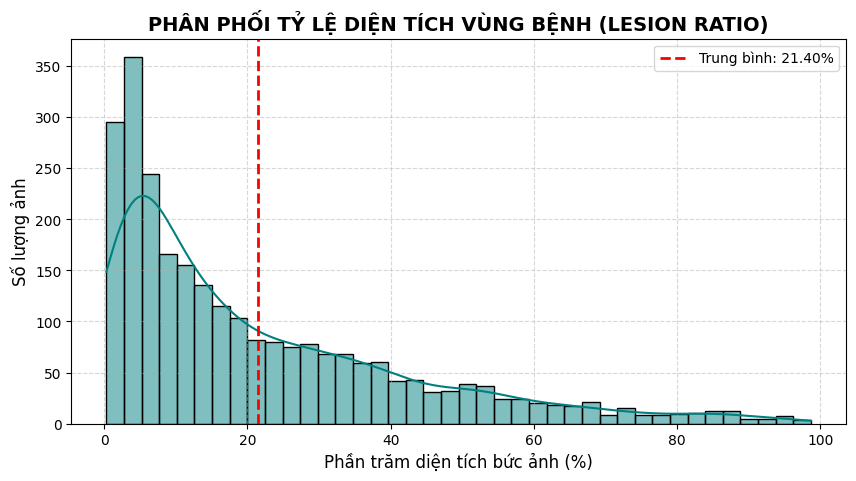

⚠️ Có 624 ảnh (24.1%) có diện tích vùng bệnh bé hơn 5% khung hình.


In [5]:
print("\n⚙️ ĐANG TÍNH TOÁN TỶ LỆ DIỆN TÍCH VÙNG BỆNH...")

lesion_ratios = []

for mask_path in tqdm(train_mask):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is not None:
        total_pixels = mask.shape[0] * mask.shape[1]

        lesion_pixels = np.sum(mask > 0)

        ratio = (lesion_pixels / total_pixels) * 100
        lesion_ratios.append(ratio)

plt.figure(figsize=(10, 5))
sns.histplot(lesion_ratios, bins=40, kde=True, color='teal')
plt.axvline(np.mean(lesion_ratios), color='red', linestyle='dashed', linewidth=2,
            label=f'Trung bình: {np.mean(lesion_ratios):.2f}%')

plt.title("PHÂN PHỐI TỶ LỆ DIỆN TÍCH VÙNG BỆNH (LESION RATIO)", fontweight='bold', fontsize=14)
plt.xlabel("Phần trăm diện tích bức ảnh (%)", fontsize=12)
plt.ylabel("Số lượng ảnh", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

small_lesions = sum(1 for r in lesion_ratios if r < 5)
print(f"⚠️ Có {small_lesions} ảnh ({small_lesions/len(lesion_ratios)*100:.1f}%) có diện tích vùng bệnh bé hơn 5% khung hình.")

📐 ĐANG THỐNG KÊ KÍCH THƯỚC ẢNH ĐỂ VẼ SCATTER PLOT...


100%|██████████| 2594/2594 [06:04<00:00,  7.12it/s]


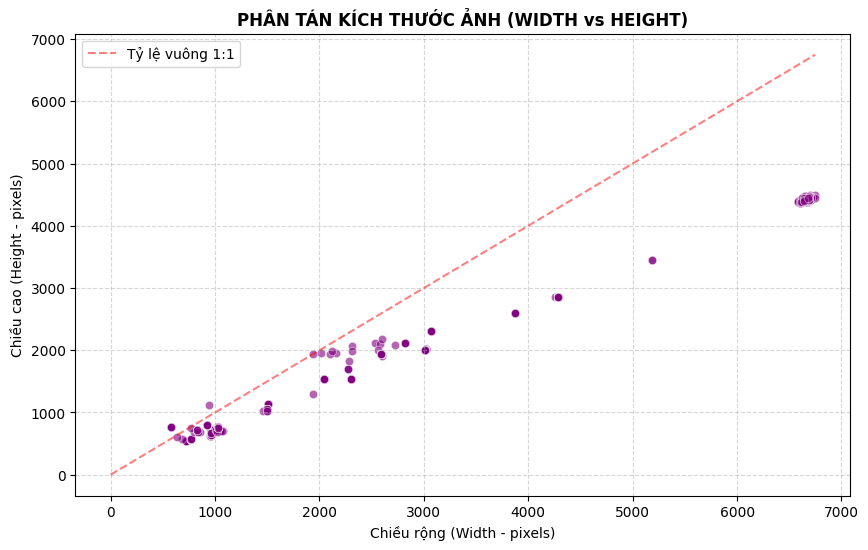

In [ ]:
print("📐 ĐANG THỐNG KÊ KÍCH THƯỚC ẢNH ĐỂ VẼ SCATTER PLOT...")

sample_paths = train_img
data = []

for path in tqdm(sample_paths):
    img = cv2.imread(path)
    if img is not None:
        height = img.shape[0] # [0] là chiều cao
        width = img.shape[1]  # [1] là chiều rộng

        data.append({
            "file_name": os.path.basename(path),
            "width": width,
            "height": height
        })

image_metadata = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=image_metadata, x="width", y="height", alpha=0.6, color="purple")

plt.title("PHÂN TÁN KÍCH THƯỚC ẢNH (WIDTH vs HEIGHT)", fontweight='bold')
plt.xlabel("Chiều rộng (Width - pixels)")
plt.ylabel("Chiều cao (Height - pixels)")
plt.grid(True, linestyle='--', alpha=0.5)

max_val = max(image_metadata['width'].max(), image_metadata['height'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', alpha=0.5, label='Tỷ lệ vuông 1:1')

plt.legend()
plt.show()

🗺️ ĐANG LẬP BẢN ĐỒ NHIỆT VỊ TRÍ TỪ TOÀN BỘ TẬP TRAIN...


100%|██████████| 2594/2594 [01:38<00:00, 26.46it/s]


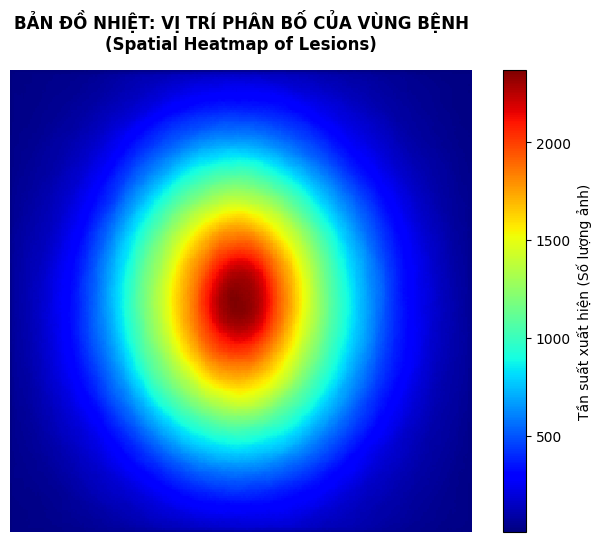

In [ ]:
print("🗺️ ĐANG LẬP BẢN ĐỒ NHIỆT VỊ TRÍ TỪ TOÀN BỘ TẬP TRAIN...")

target_size = (256, 256)
heatmap = np.zeros(target_size, dtype=np.float32)

for mask_path in tqdm(train_mask):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is not None:
        mask_resized = cv2.resize(mask, target_size)
        heatmap += (mask_resized / 255.0)

plt.figure(figsize=(8, 6))
plt.imshow(heatmap, cmap='jet', interpolation='nearest')
plt.colorbar(label='Tần suất xuất hiện (Số lượng ảnh)')
plt.title("BẢN ĐỒ NHIỆT: VỊ TRÍ PHÂN BỐ CỦA VÙNG BỆNH\n(Spatial Heatmap of Lesions)",
          fontweight='bold', pad=15)
plt.axis('off')
plt.show()

🎨 ĐANG TÍNH TOÁN THÔNG SỐ CHUẨN HÓA (MEAN & STD) CHO TẬP DỮ LIỆU...


100%|██████████| 2594/2594 [21:08<00:00,  2.05it/s]



✅ KẾT QUẢ TÍNH TOÁN (Hãy copy thông số này vào file cấu hình):
 -> MEAN (Đỏ, Xanh lá, Xanh dương): [0.7084, 0.5821, 0.5361]
 -> STD  (Đỏ, Xanh lá, Xanh dương): [0.0978, 0.1127, 0.1270]


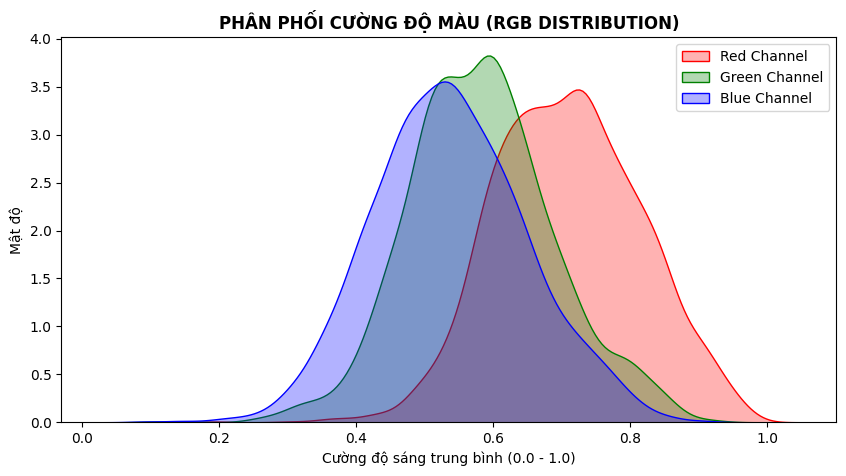

In [ ]:
print("🎨 ĐANG TÍNH TOÁN THÔNG SỐ CHUẨN HÓA (MEAN & STD) CHO TẬP DỮ LIỆU...")

sample_imgs = train_img

r_means, g_means, b_means = [], [], []
r_stds, g_stds, b_stds = [], [], []

for img_path in tqdm(sample_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_normalized = img / 255.0

    r_means.append(np.mean(img_normalized[:, :, 0]))
    g_means.append(np.mean(img_normalized[:, :, 1]))
    b_means.append(np.mean(img_normalized[:, :, 2]))

    r_stds.append(np.std(img_normalized[:, :, 0]))
    g_stds.append(np.std(img_normalized[:, :, 1]))
    b_stds.append(np.std(img_normalized[:, :, 2]))

final_mean = [np.mean(r_means), np.mean(g_means), np.mean(b_means)]
final_std  = [np.mean(r_stds), np.mean(g_stds), np.mean(b_stds)]

print("\n✅ KẾT QUẢ TÍNH TOÁN (Hãy copy thông số này vào file cấu hình):")
print(f" -> MEAN (Đỏ, Xanh lá, Xanh dương): [{final_mean[0]:.4f}, {final_mean[1]:.4f}, {final_mean[2]:.4f}]")
print(f" -> STD  (Đỏ, Xanh lá, Xanh dương): [{final_std[0]:.4f}, {final_std[1]:.4f}, {final_std[2]:.4f}]")

plt.figure(figsize=(10, 5))
sns.kdeplot(r_means, color='red', label='Red Channel', fill=True, alpha=0.3)
sns.kdeplot(g_means, color='green', label='Green Channel', fill=True, alpha=0.3)
sns.kdeplot(b_means, color='blue', label='Blue Channel', fill=True, alpha=0.3)
plt.title("PHÂN PHỐI CƯỜNG ĐỘ MÀU (RGB DISTRIBUTION)", fontweight='bold')
plt.xlabel("Cường độ sáng trung bình (0.0 - 1.0)")
plt.ylabel("Mật độ")
plt.legend()
plt.show()

⭕ ĐANG TÍNH TOÁN ĐỘ TRÒN (CIRCULARITY) CỦA VÙNG BỆNH...


100%|██████████| 2594/2594 [02:28<00:00, 17.52it/s]


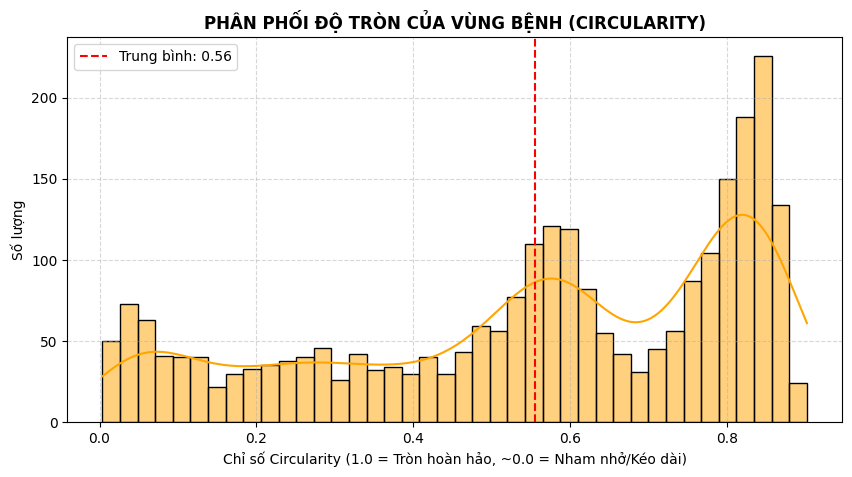

In [ ]:
print("⭕ ĐANG TÍNH TOÁN ĐỘ TRÒN (CIRCULARITY) CỦA VÙNG BỆNH...")

circularities = []

for mask_path in tqdm(train_mask):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is not None:
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True)

            if area > 100 and perimeter > 0:
                circularity = (4 * np.pi * area) / (perimeter ** 2)
                circularities.append(circularity)

plt.figure(figsize=(10, 5))
sns.histplot(circularities, bins=40, kde=True, color='orange')
plt.title("PHÂN PHỐI ĐỘ TRÒN CỦA VÙNG BỆNH (CIRCULARITY)", fontweight='bold')
plt.xlabel("Chỉ số Circularity (1.0 = Tròn hoàn hảo, ~0.0 = Nham nhở/Kéo dài)")
plt.ylabel("Số lượng")
plt.axvline(np.mean(circularities), color='red', linestyle='--', label=f'Trung bình: {np.mean(circularities):.2f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print("🔬 ĐANG PHÂN TÍCH NHIỄU LÔNG VÀ ĐỘ TƯƠNG PHẢN (DULLRAZOR & CLAHE)...")
def visualize_noise_and_contrast(img_path):
    # 1. Đọc ảnh gốc
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    grayScale = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (15, 15))

    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)

    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    img_hair_removed = cv2.inpaint(img_rgb, hair_mask, 7, cv2.INPAINT_TELEA)

    lab = cv2.cvtColor(img_hair_removed, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    img_final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Ảnh Gốc\n(Dính lông & Thiếu sáng)", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(hair_mask, cmap='gray')
    axes[1].set_title("2. Mặt nạ Lông\n(Black-Hat Filter)", fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(img_hair_removed)
    axes[2].set_title("3. Ảnh sau khi xóa lông\n(Inpainting)", fontweight='bold')
    axes[2].axis('off')

    axes[3].imshow(img_final)
    axes[3].set_title("4. Tăng tương phản (CLAHE)\n(Ranh giới nốt ruồi sắc nét)", fontweight='bold')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

sample_indices = random.sample(range(len(train_img)), 3)
for idx in sample_indices:
    visualize_noise_and_contrast(train_img[idx]) 